In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 14)

Column names: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dtypes:
 UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


=== BINARY MACHINE FAILURE ===
                 count  percentage
Machine failure                   
0                 9661       96.61
1                  339        3.39

=== FAILURE MODE BREAKDOWN ===
TWF: 46 (0.46%)
HDF: 115 (1.15%)
PWF: 95 (0.95%)
OSF: 98 (0.98%)
RNF: 19 (0.19%)


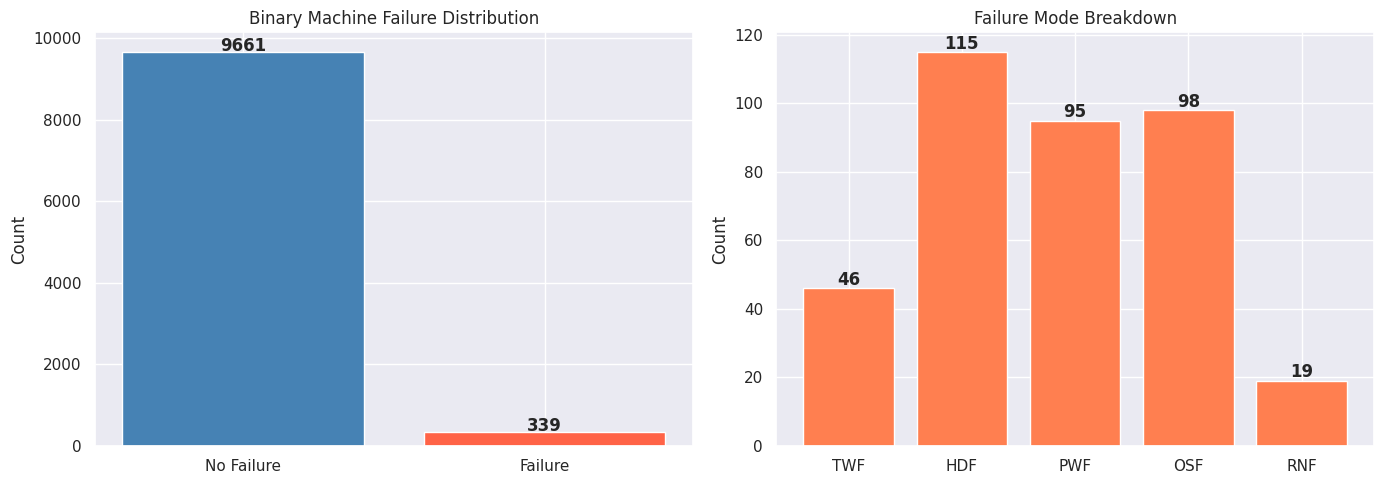


Imbalance ratio: 1 failure per 28 non-failures


In [3]:
# Binary failure label
failure_counts = df['Machine failure'].value_counts()
failure_pct = df['Machine failure'].value_counts(normalize=True) * 100

print("=== BINARY MACHINE FAILURE ===")
print(pd.DataFrame({'count': failure_counts, 'percentage': failure_pct.round(2)}))

# Individual failure modes
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("\n=== FAILURE MODE BREAKDOWN ===")
for mode in failure_modes:
    count = df[mode].sum()
    pct = (count / len(df)) * 100
    print(f"{mode}: {count} ({pct:.2f}%)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['No Failure', 'Failure'], failure_counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Binary Machine Failure Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(failure_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

mode_counts = [df[m].sum() for m in failure_modes]
axes[1].bar(failure_modes, mode_counts, color='coral')
axes[1].set_title('Failure Mode Breakdown')
axes[1].set_ylabel('Count')
for i, v in enumerate(mode_counts):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/class_imbalance.png', dpi=150)
plt.show()
print(f"\nImbalance ratio: 1 failure per {int(failure_counts[0]/failure_counts[1])} non-failures")

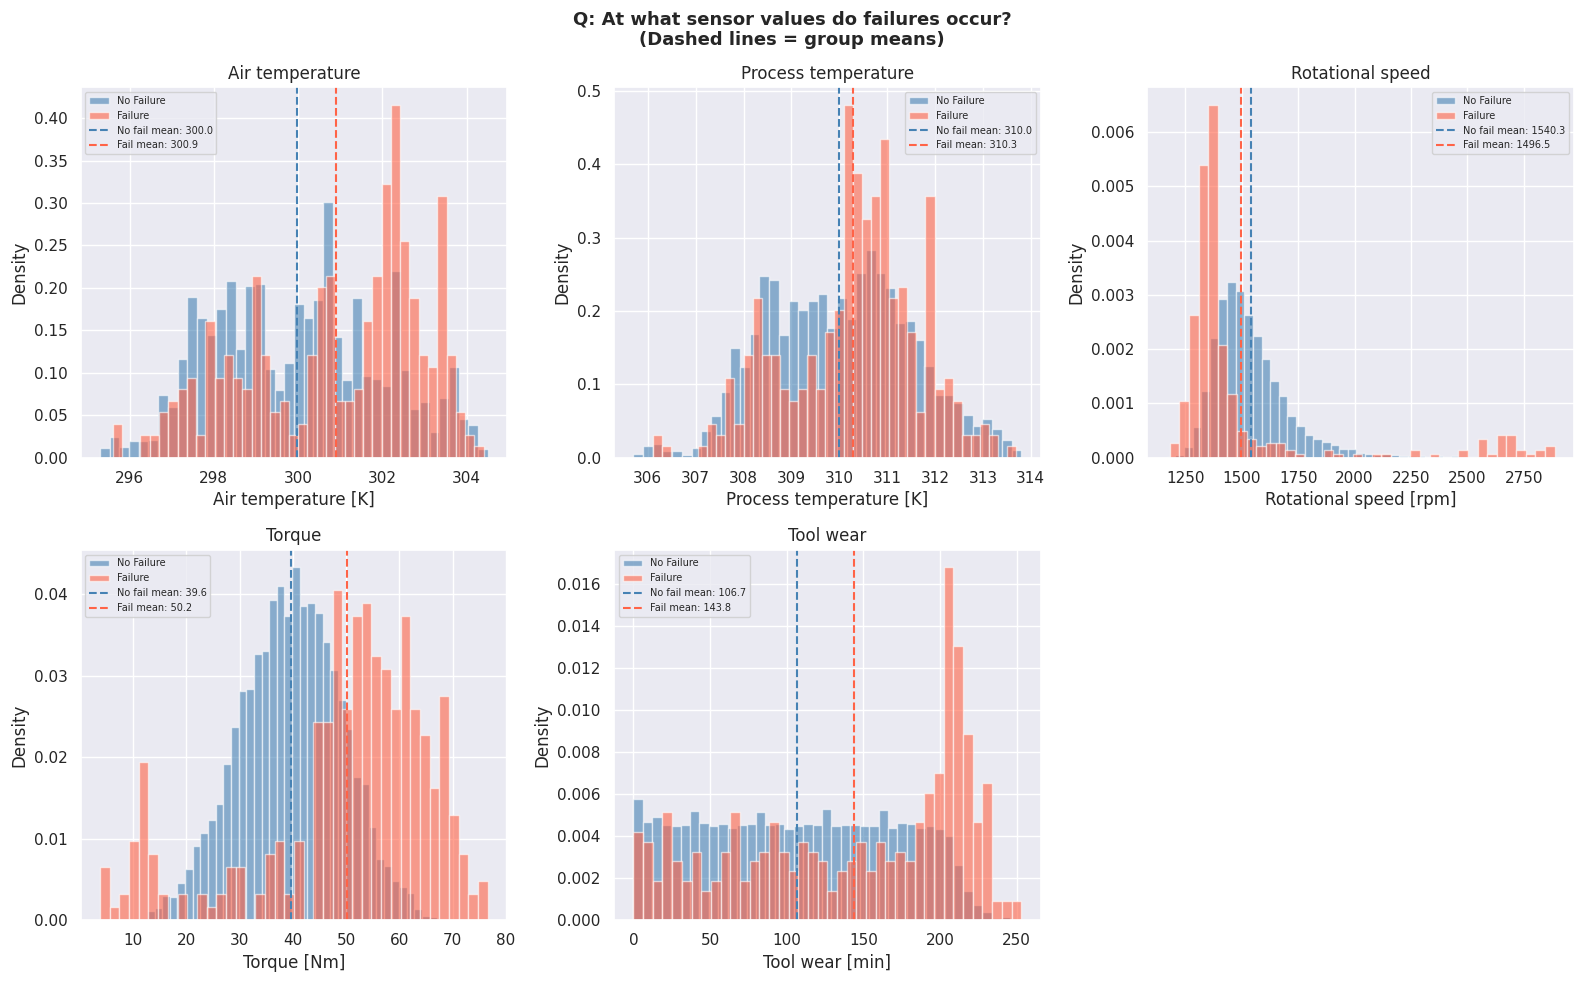

=== MEAN VALUES: FAILURE vs NO FAILURE ===
Feature                                No Failure Mean    Failure Mean   Difference
----------------------------------------------------------------------------------
Air temperature [K]                             299.97          300.89        +0.91
Process temperature [K]                         310.00          310.29        +0.29
Rotational speed [rpm]                         1540.26         1496.49       -43.77
Torque [Nm]                                      39.63           50.17       +10.54
Tool wear [min]                                 106.69          143.78       +37.09


In [4]:
# Question: At what sensor values do failures actually occur?
sensor_features = ['Air temperature [K]', 'Process temperature [K]', 
                   'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

no_fail = df[df['Machine failure'] == 0]
fail = df[df['Machine failure'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(sensor_features):
    axes[i].hist(no_fail[col], bins=40, alpha=0.6, label='No Failure', color='steelblue', density=True)
    axes[i].hist(fail[col], bins=40, alpha=0.6, label='Failure', color='tomato', density=True)
    
    # Label axes with actual units from column name
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{col.split("[")[0].strip()}')
    axes[i].legend()
    
    # Print actual mean values for each group
    no_fail_mean = no_fail[col].mean()
    fail_mean = fail[col].mean()
    axes[i].axvline(no_fail_mean, color='steelblue', linestyle='--', linewidth=1.5, label=f'No fail mean: {no_fail_mean:.1f}')
    axes[i].axvline(fail_mean, color='tomato', linestyle='--', linewidth=1.5, label=f'Fail mean: {fail_mean:.1f}')
    axes[i].legend(fontsize=7)

axes[-1].axis('off')
plt.suptitle('Q: At what sensor values do failures occur?\n(Dashed lines = group means)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/feature_distributions.png', dpi=150)
plt.show()

print("=== MEAN VALUES: FAILURE vs NO FAILURE ===")
print(f"{'Feature':<35} {'No Failure Mean':>18} {'Failure Mean':>15} {'Difference':>12}")
print("-" * 82)
for col in sensor_features:
    nf_mean = no_fail[col].mean()
    f_mean = fail[col].mean()
    diff = f_mean - nf_mean
    print(f"{col:<35} {nf_mean:>18.2f} {f_mean:>15.2f} {diff:>+12.2f}")

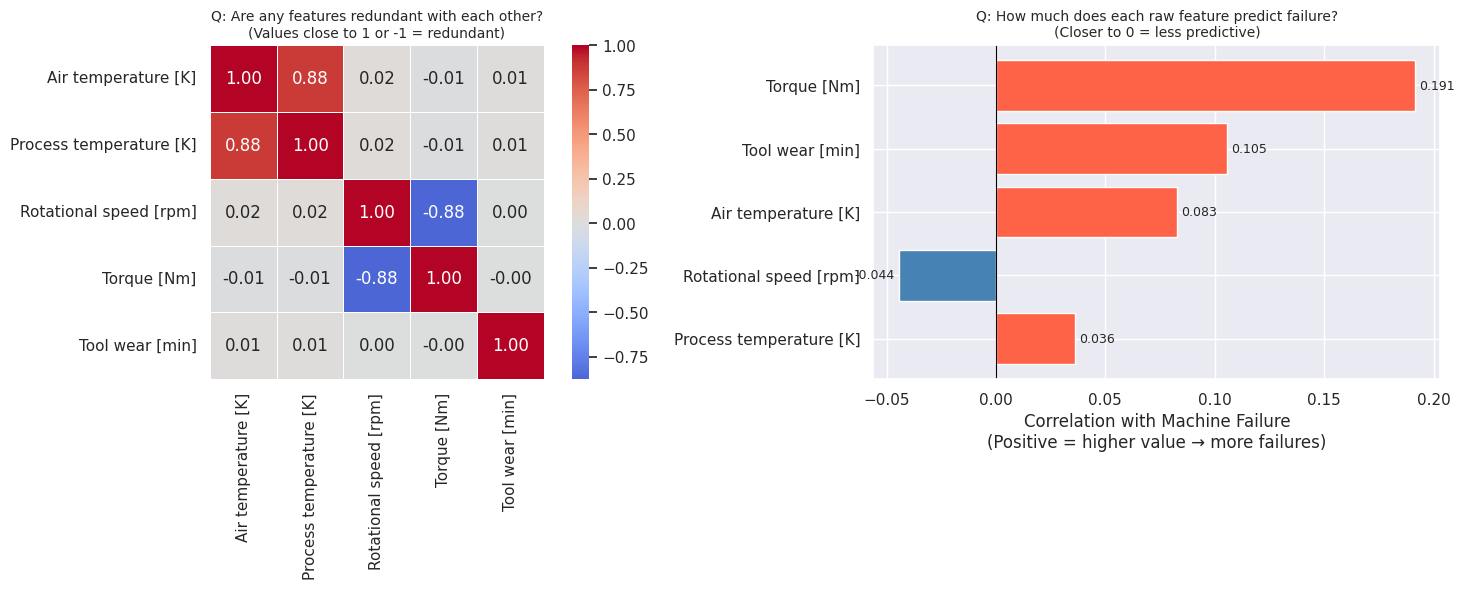

=== INTERPRETATION ===
Strongest predictor of failure: Torque [Nm] (r=0.191)

Air temp vs Process temp correlation: 0.876
  → These two are highly redundant. You don't need both as raw features.
  → Their DIFFERENCE may be more useful than either one alone.

All raw correlations with failure are below 0.20.
This means no single raw feature is a strong predictor on its own.
Feature engineering (combining features) is needed to improve this.


In [ ]:
# Question: Which features are correlated with each other, and which predict failure?

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: feature-to-feature correlation (are any raw features redundant?)
feature_corr = df[sensor_features].corr()
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Q: Are any features redundant with each other?\n(Values close to 1 or -1 = redundant)', fontsize=10)

# Right: each feature's correlation with failure label
from scipy import stats
correlations = {}
for col in sensor_features:
    r, p = stats.pointbiserialr(df['Machine failure'], df[col])
    correlations[col] = r

corr_series = pd.Series(correlations).sort_values(key=abs, ascending=True)
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_series.values]
axes[1].barh(corr_series.index, corr_series.values, color=colors)
axes[1].set_title('Q: How much does each raw feature predict failure?\n(Closer to 0 = less predictive)', fontsize=10)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlation with Machine Failure\n(Positive = higher value → more failures)')

for i, (val, name) in enumerate(zip(corr_series.values, corr_series.index)):
    axes[1].text(val + 0.002 if val >= 0 else val - 0.002, i, f'{val:.3f}', 
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/correlations.png', dpi=150)
plt.show()

print("=== INTERPRETATION ===")
top_feature = corr_series.abs().idxmax()
print(f"Strongest predictor of failure: {top_feature} (r={correlations[top_feature]:.3f})")

air_proc_corr: float = feature_corr.loc['Air temperature [K]', 'Process temperature [K]']  # type: ignore[assignment]
print(f"\nAir temp vs Process temp correlation: {air_proc_corr:.3f}")
if abs(air_proc_corr) > 0.8:
    print("  → These two are highly redundant. You don't need both as raw features.")
    print("  → Their DIFFERENCE may be more useful than either one alone.")

print(f"\nAll raw correlations with failure are below 0.20.")
print(f"This means no single raw feature is a strong predictor on its own.")
print(f"Feature engineering (combining features) is needed to improve this.")

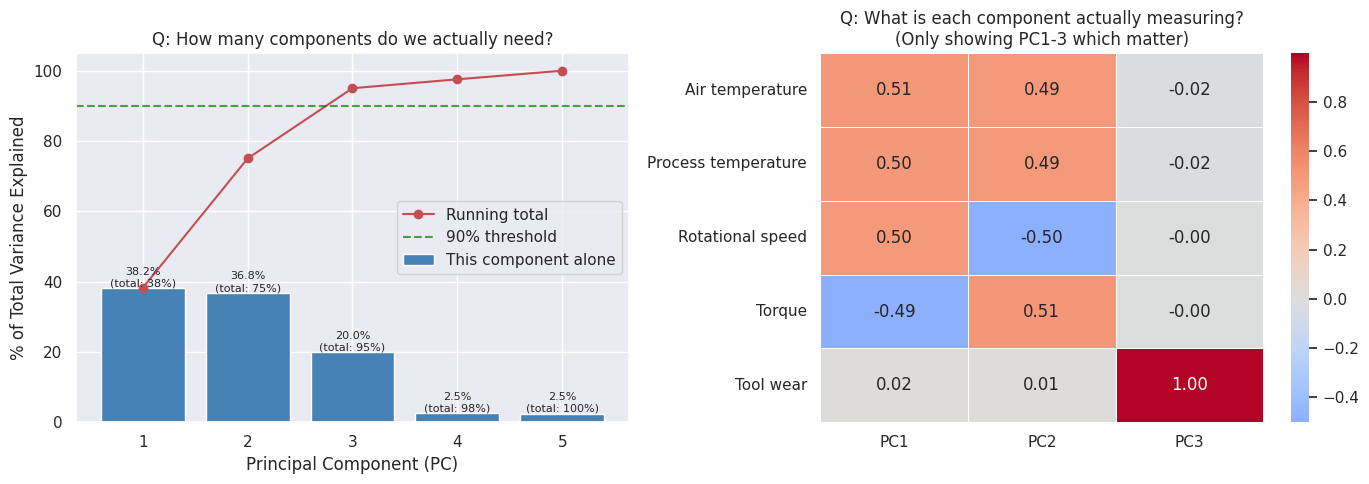

=== WHAT EACH COMPONENT ACTUALLY MEANS ===

PC1 (38.2% of variance):
  Driven mainly by: Air temperature and Process temperature

PC2 (36.8% of variance):
  Driven mainly by: Torque and Rotational speed

PC3 (20.0% of variance):
  Driven mainly by: Tool wear and Process temperature

Conclusion: 3 components capture 90% of variance.
The remaining 2 components add only 5.0% more information.
This means some raw features ARE redundant — confirming we should engineer better ones.


In [ ]:
# Question: Can we reduce 5 features down without losing information?
# And what is each principal component actually capturing?

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[sensor_features])
y = df['Machine failure'].to_numpy()

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: how much information each component carries
bars = axes[0].bar(range(1, 6), explained, color='steelblue', label='This component alone')
axes[0].plot(range(1, 6), cumulative, 'ro-', label='Running total')
axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='90% threshold')
axes[0].set_xlabel('Principal Component (PC)')
axes[0].set_ylabel('% of Total Variance Explained')
axes[0].set_title('Q: How many components do we actually need?')
axes[0].set_xticks(range(1, 6))
axes[0].legend()
for i, (v, c) in enumerate(zip(explained, cumulative)):
    axes[0].text(i+1, v+0.5, f'{v:.1f}%\n(total: {c:.0f}%)', ha='center', fontsize=8)

# Right: what each component is made of
loadings = pd.DataFrame(pca.components_[:3].T, 
                         index=[f.split('[')[0].strip() for f in sensor_features],
                         columns=['PC1', 'PC2', 'PC3'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Q: What is each component actually measuring?\n(Only showing PC1-3 which matter)')

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/pca.png', dpi=150)
plt.show()

# Plain English interpretation from actual data
print("=== WHAT EACH COMPONENT ACTUALLY MEANS ===\n")
for i in range(3):
    comp = pca.components_[i]
    top_idx = np.argsort(np.abs(comp))[::-1]
    top_feature_name = sensor_features[top_idx[0]].split('[')[0].strip()
    second_feature_name = sensor_features[top_idx[1]].split('[')[0].strip()
    print(f"PC{i+1} ({explained[i]:.1f}% of variance):")
    print(f"  Driven mainly by: {top_feature_name} and {second_feature_name}")
    print()

n_for_90 = np.argmax(cumulative >= 90) + 1
print(f"Conclusion: {n_for_90} components capture 90% of variance.")
print(f"The remaining {5 - n_for_90} components add only {100 - cumulative[n_for_90-1]:.1f}% more information.")
print(f"This means some raw features ARE redundant — confirming we should engineer better ones.")

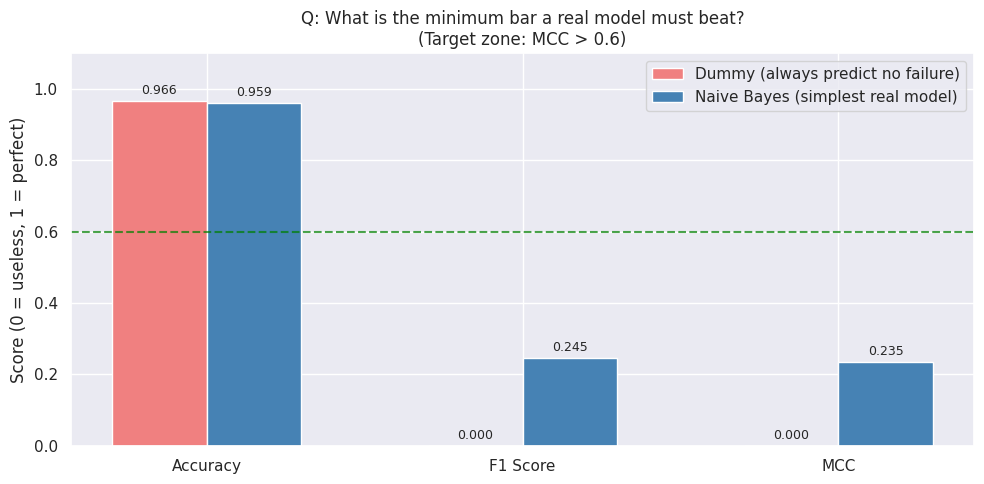

=== BASELINE RESULTS ===

Accuracy looks high for both models because 96.6% of rows are 'no failure'.
A model that predicts 'no failure' on everything gets 96.6% accuracy — but catches zero failures.
This is why we use MCC and F1 instead.

Dummy model MCC:      0.000  ← predicting nothing, this is zero
Naive Bayes MCC:      0.235 ± 0.017  ← floor to beat

Target for XGBoost after feature engineering: MCC > 0.60
Gap to close: 0.365 MCC points through better features and tuning


In [7]:
# Question: What's the minimum bar any real model must beat?

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import matthews_corrcoef, make_scorer
from sklearn.dummy import DummyClassifier

mcc_scorer = make_scorer(matthews_corrcoef)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dummy classifier — predicts majority class every time
dummy = DummyClassifier(strategy='most_frequent')
dummy_mcc = cross_val_score(dummy, X_scaled, y, cv=skf, scoring=mcc_scorer).mean()
dummy_f1 = cross_val_score(dummy, X_scaled, y, cv=skf, scoring='f1').mean()
dummy_acc = cross_val_score(dummy, X_scaled, y, cv=skf, scoring='accuracy').mean()

# Naive Bayes — simplest real model
gnb = GaussianNB()
gnb_mcc = cross_val_score(gnb, X_scaled, y, cv=skf, scoring=mcc_scorer)
gnb_f1 = cross_val_score(gnb, X_scaled, y, cv=skf, scoring='f1')
gnb_acc = cross_val_score(gnb, X_scaled, y, cv=skf, scoring='accuracy')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'F1 Score', 'MCC']
dummy_scores = [dummy_acc, dummy_f1, dummy_mcc]
gnb_scores = [gnb_acc.mean(), gnb_f1.mean(), gnb_mcc.mean()]

x = np.arange(len(metrics))
width = 0.3
ax.bar(x - width/2, dummy_scores, width, label='Dummy (always predict no failure)', color='lightcoral')
ax.bar(x + width/2, gnb_scores, width, label='Naive Bayes (simplest real model)', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (0 = useless, 1 = perfect)')
ax.set_title('Q: What is the minimum bar a real model must beat?\n(Target zone: MCC > 0.6)')
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.6, color='green', linestyle='--', alpha=0.7, label='Target MCC')

for i, (d, g) in enumerate(zip(dummy_scores, gnb_scores)):
    ax.text(i - width/2, d + 0.02, f'{d:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, g + 0.02, f'{g:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/baseline.png', dpi=150)
plt.show()

print("=== BASELINE RESULTS ===\n")
print(f"Accuracy looks high for both models because 96.6% of rows are 'no failure'.")
print(f"A model that predicts 'no failure' on everything gets {dummy_acc:.1%} accuracy — but catches zero failures.")
print(f"This is why we use MCC and F1 instead.\n")
print(f"Dummy model MCC:      {dummy_mcc:.3f}  ← predicting nothing, this is zero")
print(f"Naive Bayes MCC:      {gnb_mcc.mean():.3f} ± {gnb_mcc.std():.3f}  ← floor to beat")
print(f"\nTarget for XGBoost after feature engineering: MCC > 0.60")
print(f"Gap to close: {0.60 - gnb_mcc.mean():.3f} MCC points through better features and tuning")